# EDA

Raw Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv('aug_train.csv')

Understand Data

In [ ]:
display(df.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (19158, 14)


In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), in

Statistical Analysis

In [ ]:
print("Statistical Description:")
display(df.describe())

Statistical Description:


,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


Missing Value Check

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64


Duplicates Check

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


visualization

In [ ]:
print("Target Distribution:")
print(df['target'].value_counts())

Target Distribution:
target
0.0    14381
1.0     4777
Name: count, dtype: int64


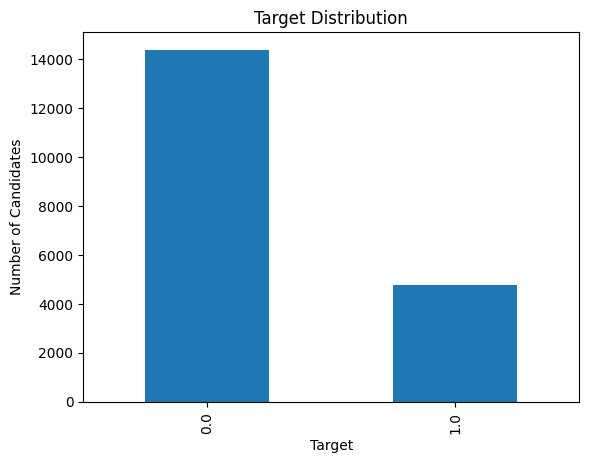

In [ ]:
df['target'].value_counts().plot(kind='bar')

plt.xlabel('Target')
plt.ylabel('Number of Candidates')
plt.title('Target Distribution')
plt.show()

categorical&numberical Analisis

In [ ]:
numeric_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['enrollee_id', 'city_development_index', 'training_hours', 'target']

Categorical Features:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


Visualization

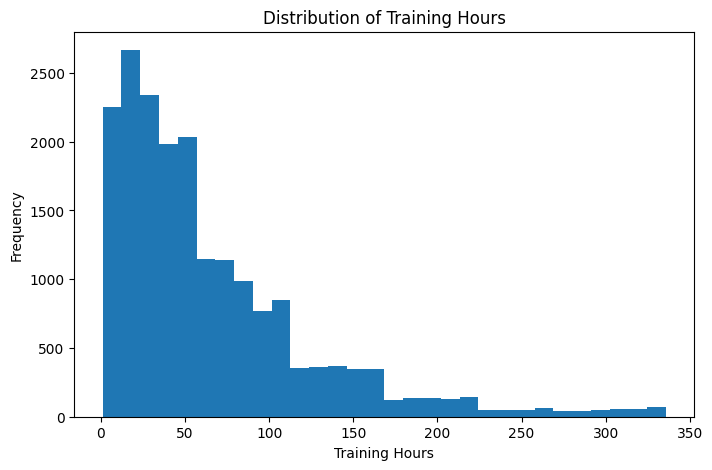

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['training_hours'].dropna(), bins=30)

plt.xlabel('Training Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Training Hours')

plt.show()

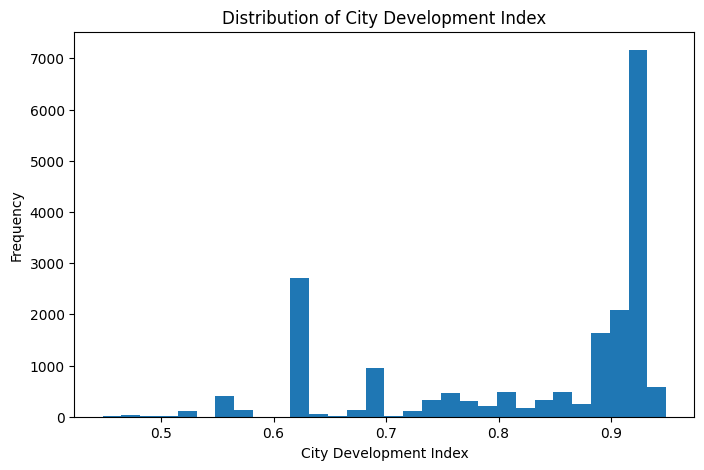

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['city_development_index'].dropna(), bins=30)

plt.xlabel('City Development Index')
plt.ylabel('Frequency')
plt.title('Distribution of City Development Index')

plt.show()

outliers Detection

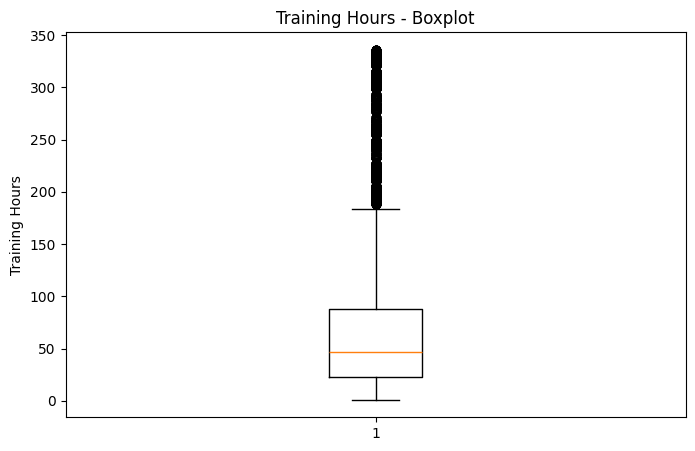

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['training_hours'].dropna())

plt.ylabel('Training Hours')
plt.title('Training Hours - Boxplot')

plt.show()

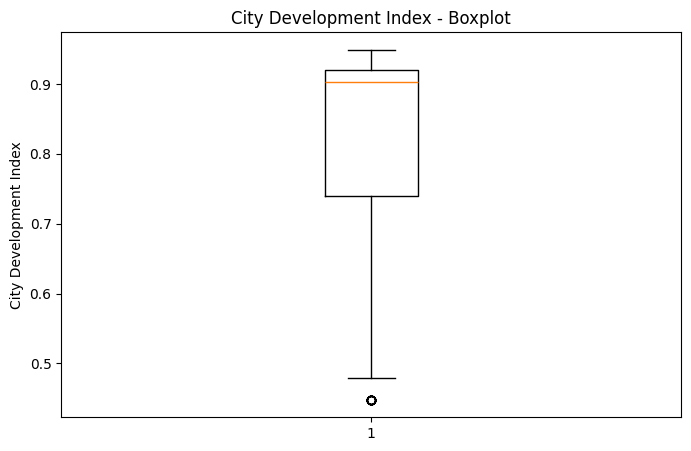

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['city_development_index'].dropna())

plt.ylabel('City Development Index')
plt.title('City Development Index - Boxplot')

plt.show()

Correlation/Relationships

<Figure size 800x500 with 0 Axes>

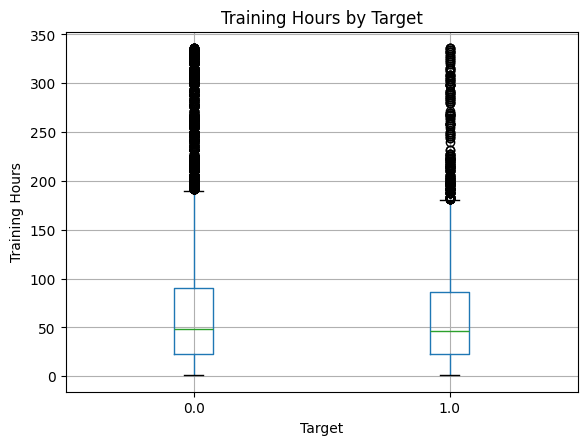

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='training_hours',
    by='target'
)

plt.xlabel('Target')
plt.ylabel('Training Hours')
plt.title('Training Hours by Target')

plt.suptitle('')

plt.show()

<Figure size 800x500 with 0 Axes>

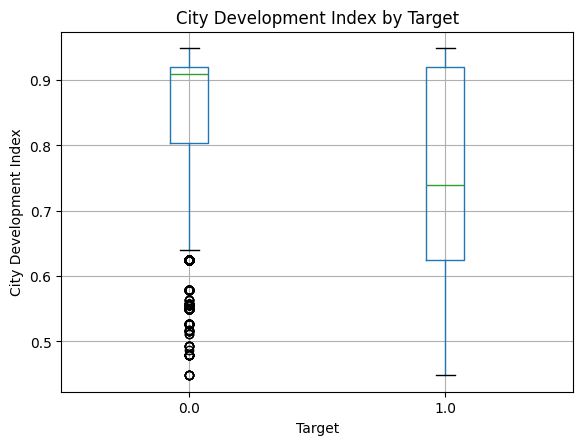

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='city_development_index',
    by='target'
)

plt.xlabel('Target')
plt.ylabel('City Development Index')
plt.title('City Development Index by Target')

plt.suptitle('')

plt.show()

identify proplem

اكتشفت من خلال تحليل البيانات ان ال
 target  غير متوازن
مع وجود بعض
outliers .في بعض . features  ال

# Data preprocessing

libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

           Encoding Original Data

In [ ]:
df_encoded = df.copy()

categorical_features = df_encoded.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoded_data = encoder.fit_transform(df_encoded[categorical_features])

encoded_columns = encoder.get_feature_names_out(categorical_features)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df_encoded.index
)

numeric_df = df_encoded.drop(columns=categorical_features)

df_encoded = pd.concat([numeric_df, encoded_df], axis=1)

display(df_encoded.head())
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

,enrollee_id,city_development_index,training_hours,target,city_city_1,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan,last_new_job_1,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never,last_new_job_nan
0,8949,0.920,36,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,29725,0.776,47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,11561,0.624,83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33241,0.789,52,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,666,0.767,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Original shape: (19158, 14)
Encoded shape: (19158, 196)


       Scale Original Numerical Data

In [ ]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

numeric_columns = df_scaled.select_dtypes(include=['int64', 'float64']).columns

scaler_df = StandardScaler()

df_scaled[numeric_columns] = scaler_df.fit_transform(
    df_scaled[numeric_columns]
)

display(df_scaled.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,-0.824285,city_103,0.738919,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,-0.488985,1.735070
1,1.336271,city_40,-0.428410,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,-0.305825,-0.576346
2,-0.552655,city_21,-1.660590,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,0.293607,-0.576346
3,1.701910,city_115,-0.323026,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,-0.222571,1.735070
4,-1.685658,city_162,-0.501368,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,-0.955209,-0.576346


Compare Before and After Scaling

In [ ]:
print("Before Scaling:")
display(df[numeric_columns].head())

print("After Scaling:")
display(df_scaled[numeric_columns].head())

print("\nMean after scaling:")
print(df_scaled[numeric_columns].mean())

print("\nStandard deviation after scaling:")
print(df_scaled[numeric_columns].std())

Before Scaling:


,enrollee_id,city_development_index,training_hours,target
0,8949,0.920,36,1.0
1,29725,0.776,47,0.0
2,11561,0.624,83,0.0
3,33241,0.789,52,1.0
4,666,0.767,8,0.0


After Scaling:


,enrollee_id,city_development_index,training_hours,target
0,-0.824285,0.738919,-0.488985,1.735070
1,1.336271,-0.428410,-0.305825,-0.576346
2,-0.552655,-1.660590,0.293607,-0.576346
3,1.701910,-0.323026,-0.222571,1.735070
4,-1.685658,-0.501368,-0.955209,-0.576346



Mean after scaling:
enrollee_id              -8.530370e-17
city_development_index   -3.464072e-16
training_hours           -7.640244e-17
target                   -1.159018e-16
dtype: float64

Standard deviation after scaling:
enrollee_id               1.000026
city_development_index    1.000026
training_hours            1.000026
target                    1.000026
dtype: float64


        Handle Duplicates

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (19158, 14)


        Handle Outliers

In [ ]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].shape[0]

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    outliers_after = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].shape[0]

    print(f"{column}")
    print(f"Outliers before handling: {outliers_before}")
    print(f"Outliers after handling: {outliers_after}")
    print("-" * 40)

    return df

In [ ]:
df = handle_outliers(df, 'training_hours')
df = handle_outliers(df, 'city_development_index')

training_hours
Outliers before handling: 984
Outliers after handling: 0
----------------------------------------
city_development_index
Outliers before handling: 17
Outliers after handling: 0
----------------------------------------


        outliers visualization

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

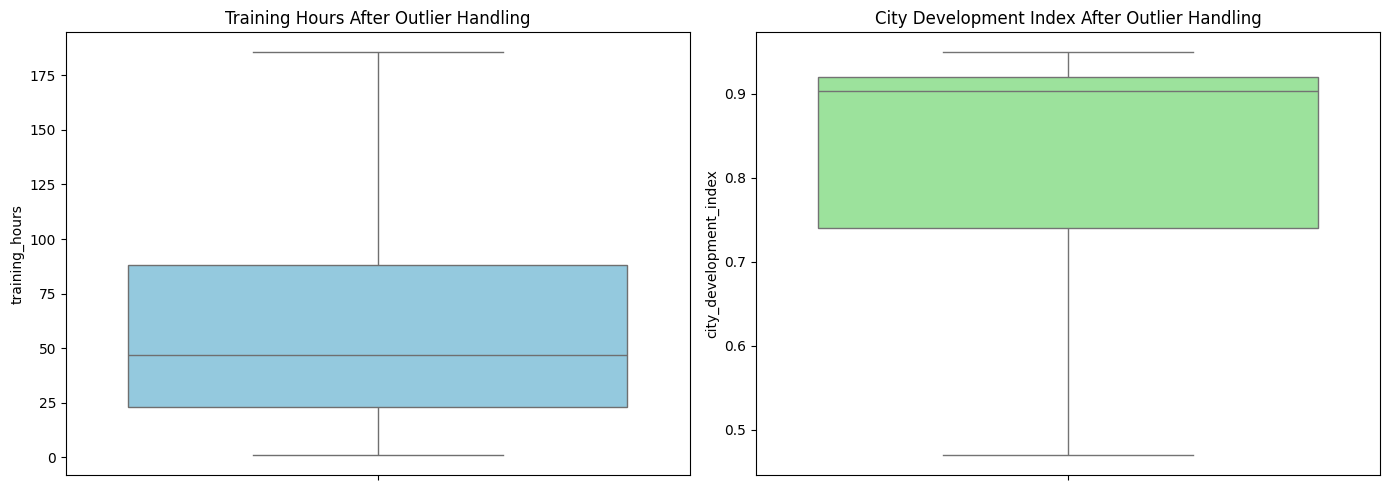

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

sns.boxplot(
    data=df,
    y='training_hours',
    color='skyblue'
)

plt.title('Training Hours After Outlier Handling')

plt.subplot(1, 2, 2)

sns.boxplot(
    data=df,
    y='city_development_index',
    color='lightgreen'
)

plt.title('City Development Index After Outlier Handling')

plt.tight_layout()
plt.show()

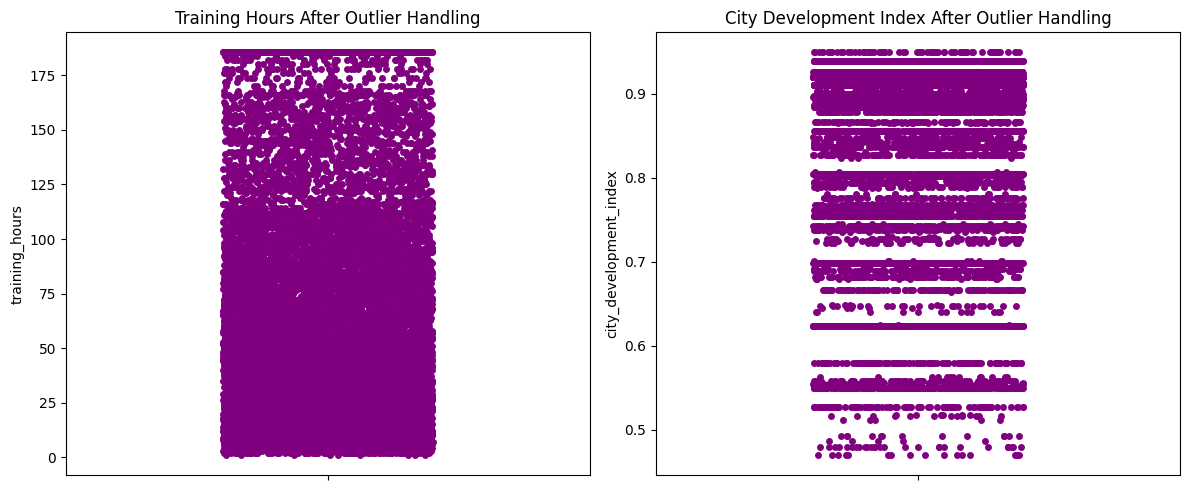

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.stripplot(
    data=df,
    y='training_hours',
    color='purple',
    jitter=0.2,
    size=5
)

plt.title('Training Hours After Outlier Handling')

plt.subplot(1, 2, 2)

sns.stripplot(
    data=df,
    y='city_development_index',
    color='purple',
    jitter=0.2,
    size=5
)

plt.title('City Development Index After Outlier Handling')

plt.tight_layout()
plt.show()

         Feature Engineering / Selection

                    Separate Features and Target

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (19158, 13)
Target Shape: (19158,)


                  Remove ID Column

In [ ]:
X = X.drop('enrollee_id', axis=1)

print("Features after removing ID:")
print(X.columns.tolist())

Features after removing ID:
['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']


               Feature Engineering

In [ ]:
X['experience_years'] = X['experience'].replace({
    '<1': 0.5,
    '>20': 21
}).astype(float)

X['high_experience'] = (X['experience_years'] >= 5).astype(int)

X['training_per_experience'] = X['training_hours'] / (X['experience_years'] + 1)

X['large_company'] = X['company_size'].isin([
    '1000-4999',
    '5000-9999',
    '10000+'
]).astype(int)

print("Feature Engineering completed successfully!")

print(X[['experience_years', 'high_experience',
         'training_per_experience', 'large_company']].head())

Feature Engineering completed successfully!
   experience_years  high_experience  training_per_experience  large_company
0              21.0                1                 1.636364              0
1              15.0                1                 2.937500              0
2               5.0                1                13.833333              0
3               0.5                0                34.666667              0
4              21.0                1                 0.363636              0


      Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15326, 16)
X_test: (3832, 16)
y_train: (15326,)
y_test: (3832,)


     Identify Numerical & Categorical Features

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['city_development_index', 'training_hours', 'experience_years', 'high_experience', 'training_per_experience', 'large_company']

Categorical Features:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


         Handle Missing Values

        Transformation-encode-scaling

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

balance

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

print("Before Balancing:")
print(y_train.value_counts())

print("\nAfter Balancing:")
print(y_train_balanced.value_counts())

Before Balancing:
target
0.0    11504
1.0     3822
Name: count, dtype: int64

After Balancing:
target
0.0    11504
1.0    11504
Name: count, dtype: int64


     Apply Full Preprocessing

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train_balanced)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train Shape:", X_train_processed.shape)
print("Processed X_test Shape:", X_test_processed.shape)

Processed X_train Shape: (23008, 189)
Processed X_test Shape: (3832, 189)


    Convert Processed Data to DataFrames

In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed= pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_balanced.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)
print("===== Data After Encoding =====")

print(X_train_processed.head())

===== Data After Encoding =====
   num__city_development_index  num__training_hours  num__experience_years  \
0                    -1.356120             0.557205               0.084776   
1                     0.849551            -0.940015              -0.663151   
2                     0.670713            -0.520794               0.383947   
3                     0.849551            -0.181423              -0.663151   
4                     0.365198             1.914686              -0.663151   

   num__high_experience  num__training_per_experience  num__large_company  \
0              0.656592                     -0.133733           -0.472143   
1              0.656592                     -0.550930           -0.472143   
2              0.656592                     -0.531161            2.118002   
3              0.656592                     -0.085895           -0.472143   
4              0.656592                      1.199071           -0.472143   

   cat__city_city_1  cat__city_city_

       Check Missing Values After Processing

In [ ]:
print("Missing values in X_train:",
      X_train_processed.isnull().sum().sum())

print("Missing values in X_test:",
      X_test_processed.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


      final data

In [ ]:
print("===== FINAL DATA =====")

print("X_train:", X_train_processed.shape)
print("X_test:", X_test_processed.shape)
print("y_train:", y_train_balanced.shape)
print("y_test:", y_test.shape)

print("\nData preprocessing completed successfully!")

===== FINAL DATA =====
X_train: (23008, 189)
X_test: (3832, 189)
y_train: (23008,)
y_test: (3832,)

Data preprocessing completed successfully!


        Save Prepared Data

In [ ]:
X_train_processed.to_csv('X_train_processed.csv', index=False)
X_test_processed.to_csv('X_test_processed.csv', index=False)
y_train_balanced.to_csv('y_train_balanced.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Prepared datasets saved successfully!")

Prepared datasets saved successfully!
